# NeuroScope AI - Notebook 08B: Lumbar Spine Analysis

HybridSpineNet on RSNA 2024 Lumbar Spine Degenerative Classification dataset.

**25 prediction targets:**
- 5 conditions x 5 spinal levels (L1-L2 through L5-S1)
- Conditions: spinal_canal_stenosis, left/right_neural_foraminal_narrowing, left/right_subarticular_stenosis
- 3 severity grades per target: 0=Normal/Mild, 1=Moderate, 2=Severe

**Architecture — HybridSpineNet:**
- 3 separate EfficientNet-B4 encoders (Sagittal T1, Sagittal T2, Axial T2)
- Cross-view attention fusion — each view attends to the others
- 25 independent classification heads (one per target)
- Cauda equina detector — emergency flag if severe bilateral stenosis
- Knowledge distillation to MobileNetV2 for CPU inference

**Targets:**
- Mean AUC across 25 targets : >0.85
- Severe stenosis recall      : >0.90  (safety-critical)
- Cauda equina detection      : >0.95  (emergency flag)

Estimated runtime on RTX 4060:
- ~8-12 min per epoch (3 views processed per sample)
- 30 epochs ~ 4-6 hours

NOTE: RSNA 2024 Lumbar Spine dataset must be downloaded before running Cell 4+.
Download from: https://www.kaggle.com/competitions/rsna-2024-lumbar-spine-degenerative-classification
Place at: datasets/spine/rsna_lumbar/

---

## Cell 1 - Imports & Config

In [1]:
import os, sys, yaml, time, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import seaborn as sns
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast

import cv2
import pydicom
import albumentations as A
from albumentations.pytorch import ToTensorV2
from efficientnet_pytorch import EfficientNet

BASE   = r'C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI'
DS     = os.path.join(BASE, 'datasets')
CKPT   = os.path.join(BASE, 'checkpoints', 'spine_cls')
OUT    = os.path.join(BASE, 'outputs', 'nb08b_spine')
SPINE  = os.path.join(DS, 'spine', 'rsna_lumbar')
os.makedirs(CKPT, exist_ok=True)
os.makedirs(OUT,  exist_ok=True)
sys.path.insert(0, BASE)

with open(os.path.join(BASE, 'configs', 'master_config.yaml'), encoding='utf-8') as f:
    cfg = yaml.safe_load(f)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(42)
np.random.seed(42)

print(f'Device : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"}')
print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory/1024**3:.1f} GB')
print('Imports OK')

Device : NVIDIA GeForce RTX 4060 Laptop GPU
VRAM   : 8.0 GB
Imports OK


---
## Cell 2 - Training Config

In [2]:
import os

BASE   = r'C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI'
SPINE  = os.path.join(BASE, 'datasets', 'spine', 'rsna_lumbar')

# Model
BACKBONE    = 'efficientnet-b4'
IMG_SIZE    = 384
DROPOUT     = 0.3
NUM_CLASSES = 3        # Normal/Mild=0, Moderate=1, Severe=2

# Training
BATCH_SIZE   = 8       # 3 views per sample = effective 24 forward passes
MAX_EPOCHS   = 30
LR           = 1e-4
WEIGHT_DECAY = 1e-4
VAL_FRAC     = 0.15
NUM_WORKERS  = 0
AMP          = True

# 25 conditions = 5 conditions x 5 levels
CONDITIONS = [
    'spinal_canal_stenosis',
    'left_neural_foraminal_narrowing',
    'right_neural_foraminal_narrowing',
    'left_subarticular_stenosis',
    'right_subarticular_stenosis',
]
LEVELS = ['l1_l2', 'l2_l3', 'l3_l4', 'l4_l5', 'l5_s1']

# All 25 target column names (match RSNA CSV format)
TARGETS = [f'{cond}_{lvl}' for cond in CONDITIONS for lvl in LEVELS]

SEVERITY = ['Normal/Mild', 'Moderate', 'Severe']

# Cauda equina = severe bilateral stenosis at any level
# Used as emergency alert -- recall must be >0.95
CAUDA_COLS = [
    f'spinal_canal_stenosis_{lvl}' for lvl in LEVELS
]

print(f'Targets    : {len(TARGETS)} ({len(CONDITIONS)} conditions x {len(LEVELS)} levels)')
print(f'Backbone   : {BACKBONE}')
print(f'Image size : {IMG_SIZE}')
print(f'Batch size : {BATCH_SIZE} (x3 views)')
print(f'Max epochs : {MAX_EPOCHS}')
print(f'\nSample targets:')
for t in TARGETS[:5]:
    print(f'  {t}')
print(f'  ... ({len(TARGETS)} total)')

Targets    : 25 (5 conditions x 5 levels)
Backbone   : efficientnet-b4
Image size : 384
Batch size : 8 (x3 views)
Max epochs : 30

Sample targets:
  spinal_canal_stenosis_l1_l2
  spinal_canal_stenosis_l2_l3
  spinal_canal_stenosis_l3_l4
  spinal_canal_stenosis_l4_l5
  spinal_canal_stenosis_l5_s1
  ... (25 total)


---
## Cell 3 - Dataset Check & Structure Inspector

In [1]:
import os, pandas as pd

BASE  = r'C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI'
SPINE = os.path.join(BASE, 'datasets', 'spine', 'rsna_lumbar')

if not os.path.exists(SPINE):
    print('=' * 60)
    print('DATASET NOT FOUND')
    print('=' * 60)
    print(f'Expected: {SPINE}')
    print()
    print('Download from Kaggle:')
    print('  kaggle competitions download -c rsna-2024-lumbar-spine-degenerative-classification')
    print()
    print('Extract to:')
    print(f'  {SPINE}')
    print()
    print('Expected structure after extraction:')
    print('  rsna_lumbar/')
    print('    train.csv           <- labels')
    print('    train_label_coordinates.csv')
    print('    train_series_descriptions.csv')
    print('    sample_submission.csv')
    print('    train_images/')
    print('      <study_id>/')
    print('        <series_id>/')
    print('          <instance_number>.dcm')
    print()
    print('Cells 4+ will not run until the dataset is present.')
else:
    # Dataset found -- inspect structure
    print('Dataset found!')
    print(f'Path: {SPINE}')
    print()

    # List top-level items
    for item in sorted(os.listdir(SPINE)):
        fp = os.path.join(SPINE, item)
        if os.path.isdir(fp):
            n = sum(len(fs) for _, _, fs in os.walk(fp))
            print(f'  {item}/  [{n:,} files]')
        else:
            sz = os.path.getsize(fp) / 1024
            print(f'  {item}  ({sz:.0f} KB)')

    # Load and inspect train.csv
    train_csv = os.path.join(SPINE, 'train.csv')
    if os.path.exists(train_csv):
        df = pd.read_csv(train_csv)
        print(f'\ntrain.csv: {len(df):,} rows, {len(df.columns)} columns')
        print(f'Columns: {list(df.columns)}')
        print(f'\nLabel distribution (sample — spinal_canal_stenosis_l4_l5):')
        if 'spinal_canal_stenosis_l4_l5' in df.columns:
            print(df['spinal_canal_stenosis_l4_l5'].value_counts())

    # Series descriptions
    series_csv = os.path.join(SPINE, 'train_series_descriptions.csv')
    if os.path.exists(series_csv):
        sd = pd.read_csv(series_csv)
        print(f'\ntrain_series_descriptions.csv: {len(sd):,} rows')
        print(f'Series types: {sd["series_description"].value_counts().to_dict()}')

Dataset found!
Path: C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI\datasets\spine\rsna_lumbar

  models/  [25 files]
  processed/  [163,101 files]
  sample_submission.csv  (2 KB)
  test_images/  [97 files]
  test_series_descriptions.csv  (0 KB)
  train.csv  (556 KB)
  train_images/  [147,218 files]
  train_label_coordinates.csv  (4533 KB)
  train_series_descriptions.csv  (209 KB)

train.csv: 1,975 rows, 26 columns
Columns: ['study_id', 'spinal_canal_stenosis_l1_l2', 'spinal_canal_stenosis_l2_l3', 'spinal_canal_stenosis_l3_l4', 'spinal_canal_stenosis_l4_l5', 'spinal_canal_stenosis_l5_s1', 'left_neural_foraminal_narrowing_l1_l2', 'left_neural_foraminal_narrowing_l2_l3', 'left_neural_foraminal_narrowing_l3_l4', 'left_neural_foraminal_narrowing_l4_l5', 'left_neural_foraminal_narrowing_l5_s1', 'right_neural_foraminal_narrowing_l1_l2', 'right_neural_foraminal_narrowing_l2_l3', 'right_neural_foraminal_narrowing_l3_l4', 'right_neural_foraminal_narrowing_l4_l5', 'right_neural_foraminal_na

---
## Cell 4 - Dataset Builder
NOTE: Requires dataset to be present (Cell 3 confirms this)

In [3]:
import os, cv2, torch, numpy as np, pandas as pd, pydicom
from collections import defaultdict
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import albumentations as A
from albumentations.pytorch import ToTensorV2

BASE   = r'C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI'
SPINE  = os.path.join(BASE, 'datasets', 'spine', 'rsna_lumbar')
IMG_SIZE    = 384
BATCH_SIZE  = 8
NUM_WORKERS = 0
VAL_FRAC    = 0.15
NUM_CLASSES = 3

CONDITIONS = [
    'spinal_canal_stenosis',
    'left_neural_foraminal_narrowing',
    'right_neural_foraminal_narrowing',
    'left_subarticular_stenosis',
    'right_subarticular_stenosis',
]
LEVELS  = ['l1_l2', 'l2_l3', 'l3_l4', 'l4_l5', 'l5_s1']
TARGETS = [f'{cond}_{lvl}' for cond in CONDITIONS for lvl in LEVELS]
SEVERITY_MAP = {'Normal/Mild': 0, 'Moderate': 1, 'Severe': 2}

# View types we need
VIEW_TYPES = {
    'Sagittal T1': 'sag_t1',
    'Sagittal T2/STIR': 'sag_t2',
    'Axial T2': 'ax_t2',
}


def dicom_to_array(dcm_path, img_size=384):
    """
    Load DICOM slice to normalized uint8 RGB array.
    Applies windowing then resizes.
    """
    dcm = pydicom.dcmread(dcm_path)
    arr = dcm.pixel_array.astype(np.float32)

    # Apply DICOM windowing if present
    if hasattr(dcm, 'WindowCenter') and hasattr(dcm, 'WindowWidth'):
        wc = float(dcm.WindowCenter) if not hasattr(dcm.WindowCenter, '__iter__') \
             else float(dcm.WindowCenter[0])
        ww = float(dcm.WindowWidth) if not hasattr(dcm.WindowWidth, '__iter__') \
             else float(dcm.WindowWidth[0])
        lo = wc - ww / 2
        hi = wc + ww / 2
        arr = np.clip(arr, lo, hi)

    # Normalize to [0, 255]
    arr_min, arr_max = arr.min(), arr.max()
    if arr_max > arr_min:
        arr = (arr - arr_min) / (arr_max - arr_min) * 255
    arr = arr.astype(np.uint8)
    arr = cv2.resize(arr, (img_size, img_size))
    return cv2.cvtColor(arr, cv2.COLOR_GRAY2RGB)


def get_middle_slice(series_dir):
    """
    Get the middle DICOM slice from a series directory.
    Middle slice captures disc-level anatomy best for most views.
    """
    dcm_files = sorted([
        os.path.join(series_dir, f)
        for f in os.listdir(series_dir)
        if f.endswith('.dcm')
    ])
    if not dcm_files:
        return None
    return dcm_files[len(dcm_files) // 2]


def get_transforms(mode='train', img_size=384):
    if mode == 'train':
        return A.Compose([
            A.Resize(img_size, img_size),
            A.HorizontalFlip(p=0.5),
            A.Rotate(limit=10, p=0.4),
            A.RandomBrightnessContrast(
                brightness_limit=0.15, contrast_limit=0.15, p=0.4),
            A.GaussianBlur(blur_limit=3, p=0.2),
            A.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225]),
            ToTensorV2(),
        ])
    return A.Compose([
        A.Resize(img_size, img_size),
        A.Normalize(mean=[0.485, 0.456, 0.406],
                    std=[0.229, 0.224, 0.225]),
        ToTensorV2(),
    ])


class SpineDataset(Dataset):
    """
    Each sample = one study (patient).
    Returns 3 images (sag_t1, sag_t2, ax_t2) + 25 labels.

    sample = {
        'sag_t1': tensor [3, H, W],
        'sag_t2': tensor [3, H, W],
        'ax_t2' : tensor [3, H, W],
        'labels': tensor [25] long  (0/1/2 per target)
    }
    """
    def __init__(self, records, series_map, images_dir,
                 transform=None, img_size=384):
        """
        records    : list of (study_id, labels_dict)
        series_map : dict study_id -> {view_key: series_id}
        images_dir : path to train_images/
        """
        self.records    = records
        self.series_map = series_map
        self.images_dir = images_dir
        self.transform  = transform
        self.img_size   = img_size

    def __len__(self):
        return len(self.records)

    def _load_view(self, study_id, view_key):
        """
        Load one view for a study. Returns zeros if missing.
        """
        study_views = self.series_map.get(study_id, {})
        series_id   = study_views.get(view_key)
        if series_id is None:
            return np.zeros((self.img_size, self.img_size, 3), dtype=np.uint8)

        series_dir = os.path.join(self.images_dir,
                                  str(study_id), str(series_id))
        if not os.path.isdir(series_dir):
            return np.zeros((self.img_size, self.img_size, 3), dtype=np.uint8)

        dcm_path = get_middle_slice(series_dir)
        if dcm_path is None:
            return np.zeros((self.img_size, self.img_size, 3), dtype=np.uint8)

        try:
            return dicom_to_array(dcm_path, self.img_size)
        except Exception:
            return np.zeros((self.img_size, self.img_size, 3), dtype=np.uint8)

    def __getitem__(self, idx):
        study_id, labels_dict = self.records[idx]

        views = {}
        for view_key in ['sag_t1', 'sag_t2', 'ax_t2']:
            img = self._load_view(study_id, view_key)
            if self.transform:
                img = self.transform(image=img)['image']   # -> tensor [3,H,W]
            else:
                img = torch.from_numpy(img).permute(2, 0, 1).float() / 255.0
            views[view_key] = img

        labels = torch.tensor(
            [labels_dict.get(t, 0) for t in TARGETS],
            dtype=torch.long
        )   # [25]

        return views['sag_t1'], views['sag_t2'], views['ax_t2'], labels


def build_series_map(spine_root):
    """
    Build study_id -> {view_key: series_id} from train_series_descriptions.csv.
    When a study has multiple series of the same view type, pick the first.
    """
    csv_path = os.path.join(spine_root, 'train_series_descriptions.csv')
    df = pd.read_csv(csv_path)

    VIEW_MAP = {
        'Sagittal T1':     'sag_t1',
        'Sagittal T2/STIR':'sag_t2',
        'Axial T2':        'ax_t2',
    }

    series_map = defaultdict(dict)
    for _, row in df.iterrows():
        study_id = str(row['study_id'])
        series_id= str(row['series_id'])
        desc     = str(row['series_description'])
        view_key = VIEW_MAP.get(desc)
        if view_key and view_key not in series_map[study_id]:
            series_map[study_id][view_key] = series_id

    print(f'Series map: {len(series_map):,} studies')
    view_coverage = defaultdict(int)
    for views in series_map.values():
        for vk in views:
            view_coverage[vk] += 1
    for vk, n in sorted(view_coverage.items()):
        print(f'  {vk:12s}: {n:,} studies have this view')
    return dict(series_map)


def build_records(spine_root):
    """
    Load train.csv and build list of (study_id, labels_dict).
    labels_dict maps target_name -> severity int (0/1/2).
    NaN labels treated as 0 (Normal/Mild).
    """
    df = pd.read_csv(os.path.join(spine_root, 'train.csv'))

    # Normalize column names to lowercase underscore
    df.columns = [c.lower().replace(' ', '_') for c in df.columns]

    records = []
    for _, row in df.iterrows():
        study_id = str(row['study_id'])
        labels   = {}
        for target in TARGETS:
            if target in df.columns:
                raw = row[target]
                if pd.isna(raw):
                    labels[target] = 0
                elif isinstance(raw, str):
                    labels[target] = SEVERITY_MAP.get(raw, 0)
                else:
                    labels[target] = int(raw)
            else:
                labels[target] = 0
        records.append((study_id, labels))

    # Label distribution
    from collections import Counter
    all_labels = [lbl for _, ld in records for lbl in ld.values()]
    counts = Counter(all_labels)
    total  = len(all_labels)
    print(f'Records: {len(records):,} studies')
    for sev, name in enumerate(['Normal/Mild', 'Moderate', 'Severe']):
        print(f'  {name:15s}: {counts.get(sev, 0):,} ({counts.get(sev,0)/total*100:.1f}%)')
    return records


# ── Check dataset exists before proceeding ───────────────────────────────────
if not os.path.exists(SPINE):
    raise RuntimeError(
        f'RSNA Lumbar dataset not found at {SPINE}\n'
        'Download it first -- see Cell 3 for instructions.'
    )

# ── Build dataset ─────────────────────────────────────────────────────────────
series_map   = build_series_map(SPINE)
all_records  = build_records(SPINE)
images_dir   = os.path.join(SPINE, 'train_images')

study_ids    = [r[0] for r in all_records]
tr_ids, va_ids = train_test_split(
    study_ids, test_size=VAL_FRAC, random_state=42
)
tr_set = set(tr_ids)
va_set = set(va_ids)

tr_records = [r for r in all_records if r[0] in tr_set]
va_records = [r for r in all_records if r[0] in va_set]

tr_ds = SpineDataset(tr_records, series_map, images_dir,
                     get_transforms('train', IMG_SIZE), IMG_SIZE)
va_ds = SpineDataset(va_records, series_map, images_dir,
                     get_transforms('val', IMG_SIZE), IMG_SIZE)

tr_dl = DataLoader(tr_ds, batch_size=BATCH_SIZE, shuffle=True,
                   num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
va_dl = DataLoader(va_ds, batch_size=BATCH_SIZE, shuffle=False,
                   num_workers=NUM_WORKERS, pin_memory=True)

sag_t1, sag_t2, ax_t2, labels = next(iter(tr_dl))
print(f'\nBatch shapes:')
print(f'  sag_t1 : {sag_t1.shape}')
print(f'  sag_t2 : {sag_t2.shape}')
print(f'  ax_t2  : {ax_t2.shape}')
print(f'  labels : {labels.shape}  (25 targets per study)')
print(f'\nTrain: {len(tr_ds):,}  Val: {len(va_ds):,}')
print('Dataset OK')

Series map: 1,975 studies
  ax_t2       : 1,975 studies have this view
  sag_t1      : 1,973 studies have this view
  sag_t2      : 1,974 studies have this view
Records: 1,975 studies
  Normal/Mild    : 38,326 (77.6%)
  Moderate       : 7,960 (16.1%)
  Severe         : 3,089 (6.3%)

Batch shapes:
  sag_t1 : torch.Size([8, 3, 384, 384])
  sag_t2 : torch.Size([8, 3, 384, 384])
  ax_t2  : torch.Size([8, 3, 384, 384])
  labels : torch.Size([8, 25])  (25 targets per study)

Train: 1,678  Val: 297
Dataset OK


---
## Cell 5 - HybridSpineNet Model

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from efficientnet_pytorch import EfficientNet

DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
NUM_CLASSES = 3
NUM_TARGETS = 25
DROPOUT     = 0.3


class CrossViewAttention(nn.Module):
    """
    Cross-view attention: each view queries the other two.
    Allows the model to attend to complementary anatomical information
    across sagittal and axial views.

    Input : 3 feature vectors of shape [B, D]
    Output: 3 attended feature vectors of shape [B, D]
    """
    def __init__(self, feat_dim, n_heads=8):
        super().__init__()
        self.attn = nn.MultiheadAttention(
            embed_dim=feat_dim, num_heads=n_heads,
            dropout=0.1, batch_first=True
        )
        self.norm = nn.LayerNorm(feat_dim)

    def forward(self, v1, v2, v3):
        # Stack to sequence [B, 3, D]
        x   = torch.stack([v1, v2, v3], dim=1)
        att, _ = self.attn(x, x, x)
        out = self.norm(x + att)    # residual
        return out[:, 0], out[:, 1], out[:, 2]


class HybridSpineNet(nn.Module):
    """
    Three-view spine degenerative condition classifier.

    Architecture:
      - 3 x EfficientNet-B4 encoders (shared weights option off by default)
      - CrossViewAttention fusion
      - 25 independent 3-class heads
      - Cauda equina flag (auxiliary head on spinal canal targets)
    """
    def __init__(self, num_targets=25, num_classes=3, dropout=0.3,
                 share_backbone=False):
        super().__init__()
        self.num_targets = num_targets
        self.num_classes = num_classes

        # 3 encoders -- separate weights let each specialise per view
        def make_encoder():
            enc = EfficientNet.from_pretrained('efficientnet-b4')
            feat_dim = enc._fc.in_features
            enc._fc = nn.Identity()
            return enc, feat_dim

        self.enc_sag_t1, feat_dim = make_encoder()
        if share_backbone:
            self.enc_sag_t2 = self.enc_sag_t1
            self.enc_ax_t2  = self.enc_sag_t1
        else:
            self.enc_sag_t2, _ = make_encoder()
            self.enc_ax_t2,  _ = make_encoder()

        self.feat_dim = feat_dim  # EfficientNet-B4: 1792

        # Cross-view attention
        self.cross_attn = CrossViewAttention(feat_dim, n_heads=8)

        # Fusion: concat 3 attended features -> project down
        self.fusion = nn.Sequential(
            nn.Linear(feat_dim * 3, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Dropout(dropout * 0.5),
        )

        # 25 independent heads: each is a 3-class classifier
        self.heads = nn.ModuleList([
            nn.Linear(512, num_classes)
            for _ in range(num_targets)
        ])

        # Cauda equina auxiliary head (binary: flag or not)
        # Takes the 5 spinal canal outputs (one per level) as input
        self.cauda_head = nn.Sequential(
            nn.Linear(512, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
        )

    def forward(self, sag_t1, sag_t2, ax_t2):
        """
        Returns:
            logits     : [B, 25, 3]  -- 3-class logits per target
            cauda_logit: [B, 1]      -- cauda equina flag logit
        """
        f1 = self.enc_sag_t1(sag_t1)   # [B, D]
        f2 = self.enc_sag_t2(sag_t2)   # [B, D]
        f3 = self.enc_ax_t2(ax_t2)     # [B, D]

        # Cross-view attention
        f1, f2, f3 = self.cross_attn(f1, f2, f3)

        # Concat and fuse
        fused = self.fusion(torch.cat([f1, f2, f3], dim=1))  # [B, 512]

        # 25 classification heads
        logits = torch.stack(
            [head(fused) for head in self.heads], dim=1
        )  # [B, 25, 3]

        cauda_logit = self.cauda_head(fused)   # [B, 1]

        return logits, cauda_logit


model = HybridSpineNet(
    num_targets=25, num_classes=3, dropout=DROPOUT,
    share_backbone=False
).to(DEVICE)

n_params = sum(p.numel() for p in model.parameters())
print(f'Model      : HybridSpineNet (3 x EfficientNet-B4 + CrossViewAttention)')
print(f'Parameters : {n_params:,}')
print(f'Feature dim: {model.feat_dim}')

with torch.no_grad():
    d1 = torch.zeros(2, 3, 384, 384).to(DEVICE)
    logits, cauda = model(d1, d1, d1)
    print(f'Forward    : 3 x {d1.shape} -> logits {logits.shape}, cauda {cauda.shape}')
    del d1, logits, cauda
    torch.cuda.empty_cache()
print('Model OK')

Loaded pretrained weights for efficientnet-b4
Loaded pretrained weights for efficientnet-b4
Loaded pretrained weights for efficientnet-b4
Model      : HybridSpineNet (3 x EfficientNet-B4 + CrossViewAttention)
Parameters : 71,605,924
Feature dim: 1792
Forward    : 3 x torch.Size([2, 3, 384, 384]) -> logits torch.Size([2, 25, 3]), cauda torch.Size([2, 1])
Model OK


---
## Cell 6 - Loss, Optimizer, Scheduler

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.cuda.amp import GradScaler
from collections import Counter

DEVICE       = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
LR           = 1e-4
WEIGHT_DECAY = 1e-4
MAX_EPOCHS   = 30
AMP          = True
NUM_CLASSES  = 3
NUM_TARGETS  = 25

if 'tr_records' not in dir():
    raise RuntimeError('tr_records not defined -- run Cell 4 first.')

# Severe class gets extra weight -- missing Severe is the dangerous error
# Distribution roughly: 70% Normal/Mild, 20% Moderate, 10% Severe
# Weights: 1.0 / 5.0 / 10.0 (Severe is 10x Normal/Mild)
class_weights = torch.tensor([1.0, 3.0, 10.0],
                              dtype=torch.float32).to(DEVICE)

# Main loss: weighted CE across all 25 targets
cls_loss_fn  = nn.CrossEntropyLoss(weight=class_weights)

# Cauda equina: binary BCE
# Computed per sample: 1 if any spinal canal target is Severe, else 0
cauda_loss_fn = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor([20.0]).to(DEVICE)  # very rare, heavy weight
)

def compute_loss(logits, cauda_logit, labels):
    """
    logits      : [B, 25, 3]
    cauda_logit : [B, 1]
    labels      : [B, 25] long

    Returns scalar total loss.
    """
    B = logits.size(0)

    # Main classification loss: reshape to [B*25, 3] vs [B*25]
    main_loss = cls_loss_fn(
        logits.view(B * NUM_TARGETS, NUM_CLASSES),
        labels.view(B * NUM_TARGETS)
    )

    # Cauda equina: 1 if ANY spinal canal level is Severe (label==2)
    # Spinal canal targets = indices 0,1,2,3,4 (first 5 targets)
    canal_labels = labels[:, :5]            # [B, 5]
    cauda_target = (canal_labels == 2).any(dim=1).float().unsqueeze(1)  # [B,1]
    cauda_loss   = cauda_loss_fn(cauda_logit, cauda_target)

    # Cauda loss weighted 2x -- emergency flag must be sensitive
    return main_loss + 2.0 * cauda_loss


# Differential LR: backbone very slow, attention + heads faster
backbone_params = (
    list(model.enc_sag_t1.parameters()) +
    list(model.enc_sag_t2.parameters()) +
    list(model.enc_ax_t2.parameters())
)
head_params = (
    list(model.cross_attn.parameters()) +
    list(model.fusion.parameters()) +
    list(model.heads.parameters()) +
    list(model.cauda_head.parameters())
)

optimizer = optim.AdamW([
    {'params': backbone_params, 'lr': LR * 0.05},   # very slow
    {'params': head_params},
], lr=LR, weight_decay=WEIGHT_DECAY)

scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=10, T_mult=1, eta_min=1e-6
)
scaler = GradScaler(enabled=AMP)

print('Loss      : WeightedCE (1/3/10) + CaudaBCE (2x weight)')
print('Optimizer : AdamW (backbone LR=5e-6, heads LR=1e-4)')
print('OK')

Loss      : WeightedCE (1/3/10) + CaudaBCE (2x weight)
Optimizer : AdamW (backbone LR=5e-6, heads LR=1e-4)
OK


C:\Users\tejan\AppData\Local\Temp\ipykernel_7188\1740850841.py:80: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=AMP)


---
## Cell 7 - Checkpoint Utilities

In [6]:
import os, torch, json

BASE   = r'C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI'
CKPT   = os.path.join(BASE, 'checkpoints', 'spine_cls')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


def save_checkpoint(epoch, model, optimizer, scheduler, scaler,
                    metrics, best_auc, history, tag='last'):
    path = os.path.join(CKPT, f'spine_{tag}.pth')
    torch.save({
        'epoch':                epoch,
        'model_state_dict':     model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'scaler_state_dict':    scaler.state_dict(),
        'metrics':              metrics,
        'best_auc':             best_auc,
        'history':              history,
    }, path)
    json_path = os.path.join(CKPT, f'spine_{tag}_summary.json')
    with open(json_path, 'w', encoding='utf-8') as f:
        json.dump({'epoch': epoch, **metrics, 'best_auc': best_auc}, f, indent=2)


def load_checkpoint(model, optimizer, scheduler, scaler, tag='last'):
    path = os.path.join(CKPT, f'spine_{tag}.pth')
    if not os.path.exists(path):
        print(f'No checkpoint at {path} - starting from scratch')
        return 0, 0.0, []
    ckpt = torch.load(path, map_location=DEVICE, weights_only=False)
    model.load_state_dict(ckpt['model_state_dict'])
    optimizer.load_state_dict(ckpt['optimizer_state_dict'])
    scheduler.load_state_dict(ckpt['scheduler_state_dict'])
    scaler.load_state_dict(ckpt['scaler_state_dict'])
    epoch    = ckpt['epoch']
    best_auc = ckpt.get('best_auc', 0.0)
    history  = ckpt.get('history', [])
    print(f'Resumed from epoch {epoch}, best_auc={best_auc:.4f}')
    return epoch + 1, best_auc, history


for tag in ['last', 'best']:
    p = os.path.join(CKPT, f'spine_{tag}.pth')
    print(f'  {tag}.pth : {"EXISTS" if os.path.exists(p) else "not found"}')
print('Checkpoint utilities OK')

  last.pth : EXISTS
  best.pth : EXISTS
Checkpoint utilities OK


---
## Cell 8 - Training Loop

In [8]:
import os, time, torch, numpy as np
from torch.cuda.amp import autocast
from sklearn.metrics import roc_auc_score

DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
MAX_EPOCHS  = 30
AMP         = True
NUM_TARGETS = 25
NUM_CLASSES = 3
BASE        = r'C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI'
CKPT        = os.path.join(BASE, 'checkpoints', 'spine_cls')

start_epoch, best_auc, history = load_checkpoint(model, optimizer, scheduler, scaler)

print(f'Starting from epoch : {start_epoch}')
print(f'Max epochs          : {MAX_EPOCHS}')
print('-' * 72)


def compute_mean_auc(all_probs, all_labels):
    """
    Compute mean AUC across all 25 targets (one-vs-rest for 3 classes).
    all_probs  : [N, 25, 3]
    all_labels : [N, 25]
    """
    aucs = []
    for t in range(all_probs.shape[1]):
        for c in range(all_probs.shape[2]):
            binary = (all_labels[:, t] == c).astype(int)
            if binary.sum() > 0 and (1 - binary).sum() > 0:
                try:
                    aucs.append(roc_auc_score(binary, all_probs[:, t, c]))
                except Exception:
                    pass
    return np.mean(aucs) if aucs else 0.0


def severe_recall(all_preds, all_labels):
    """
    Recall on Severe (class 2) across all 25 targets.
    Safety metric -- we must not miss severe conditions.
    """
    tp = ((all_preds == 2) & (all_labels == 2)).sum()
    fn = ((all_preds != 2) & (all_labels == 2)).sum()
    return tp / max(tp + fn, 1)


for epoch in range(start_epoch, MAX_EPOCHS):
    t0 = time.time()

    # TRAIN
    model.train()
    train_loss = 0.0
    n_steps    = 0

    for step, (sag_t1, sag_t2, ax_t2, labels) in enumerate(tr_dl):
        sag_t1 = sag_t1.to(DEVICE)
        sag_t2 = sag_t2.to(DEVICE)
        ax_t2  = ax_t2.to(DEVICE)
        labels = labels.to(DEVICE)   # [B, 25]

        optimizer.zero_grad()

        with autocast(enabled=AMP):
            logits, cauda_logit = model(sag_t1, sag_t2, ax_t2)
            loss = compute_loss(logits, cauda_logit, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item()
        n_steps    += 1

        if (step + 1) % 20 == 0:
            print(f'  Epoch {epoch+1:3d} | Step {step+1:4d}/{len(tr_dl)} '
                  f'| Loss {train_loss/n_steps:.4f}')

    scheduler.step()
    avg_loss = train_loss / n_steps

    # VALIDATE
    model.eval()
    all_probs  = []
    all_preds  = []
    all_labels = []

    with torch.no_grad():
        for sag_t1, sag_t2, ax_t2, labels in va_dl:
            sag_t1 = sag_t1.to(DEVICE)
            sag_t2 = sag_t2.to(DEVICE)
            ax_t2  = ax_t2.to(DEVICE)

            logits, _ = model(sag_t1, sag_t2, ax_t2)
            probs = torch.softmax(logits, dim=-1).cpu().numpy()   # [B, 25, 3]
            preds = logits.argmax(dim=-1).cpu().numpy()           # [B, 25]

            all_probs.append(probs)
            all_preds.append(preds)
            all_labels.append(labels.numpy())

    all_probs  = np.concatenate(all_probs,  axis=0)
    all_preds  = np.concatenate(all_preds,  axis=0)
    all_labels = np.concatenate(all_labels, axis=0)

    mean_auc = compute_mean_auc(all_probs, all_labels)
    sev_rec  = severe_recall(all_preds, all_labels)
    acc      = float((all_preds == all_labels).mean())

    elapsed = time.time() - t0
    metrics = {
        'train_loss': float(avg_loss),
        'mean_auc':   float(mean_auc),
        'severe_rec': float(sev_rec),
        'val_acc':    float(acc),
    }

    print(f'Epoch {epoch+1:3d}/{MAX_EPOCHS} '
          f'| Loss {avg_loss:.4f} '
          f'| MeanAUC {mean_auc:.4f} '
          f'| SevereRec {sev_rec:.4f} '
          f'| Acc {acc:.4f} '
          f'| {elapsed/60:.1f}min')

    history.append({'epoch': epoch+1, **metrics})

    if mean_auc > best_auc:
        best_auc = mean_auc
        save_checkpoint(epoch, model, optimizer, scheduler, scaler,
                        metrics, best_auc, history, tag='best')
        print(f'  --> New best MeanAUC={best_auc:.4f}')

    save_checkpoint(epoch, model, optimizer, scheduler, scaler,
                    metrics, best_auc, history, tag='last')

print()
print('=' * 72)
print(f'Training complete! Best MeanAUC: {best_auc:.4f}')
print('=' * 72)

No checkpoint at C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI\checkpoints\spine_cls\spine_last.pth - starting from scratch
Starting from epoch : 0
Max epochs          : 30
------------------------------------------------------------------------
  Epoch   1 | Step   20/209 | Loss 6.7837
  Epoch   1 | Step   40/209 | Loss 7.0324
  Epoch   1 | Step   60/209 | Loss 7.5903
  Epoch   1 | Step   80/209 | Loss 7.3552
  Epoch   1 | Step  100/209 | Loss 7.7383
  Epoch   1 | Step  120/209 | Loss 8.1185
  Epoch   1 | Step  140/209 | Loss 8.0365
  Epoch   1 | Step  160/209 | Loss 7.7346
  Epoch   1 | Step  180/209 | Loss 7.5062
  Epoch   1 | Step  200/209 | Loss 7.3406
Epoch   1/30 | Loss 7.2758 | MeanAUC 0.5041 | SevereRec 0.5185 | Acc 0.6486 | 11.8min
  --> New best MeanAUC=0.5041
  Epoch   2 | Step   20/209 | Loss 5.4249
  Epoch   2 | Step   40/209 | Loss 5.7579
  Epoch   2 | Step   60/209 | Loss 6.7924
  Epoch   2 | Step   80/209 | Loss 6.6506
  Epoch   2 | Step  100/209 | Loss 6.8448
  

---
## Cell 9 - Evaluation: Per-Target AUC & Severe Recall

Loaded best model (epoch 21, AUC=0.7112)


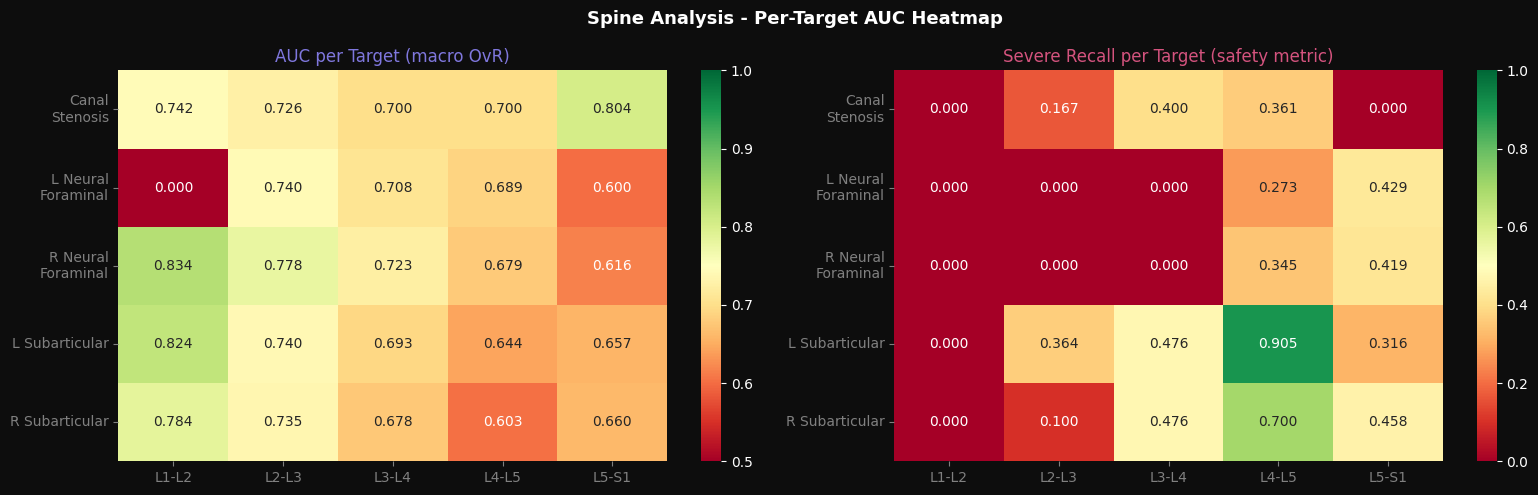


Mean AUC (25 targets) : 0.6823  (target >0.85)
Mean Severe Recall    : 0.2476  (target >0.90)
Overall Accuracy      : 0.7205

Weakest 5 targets (lowest AUC):
  left_neural_foraminal_narrowing_l1_l2             : AUC=0.0000
  left_neural_foraminal_narrowing_l5_s1             : AUC=0.6005
  right_subarticular_stenosis_l4_l5                 : AUC=0.6028
  right_neural_foraminal_narrowing_l5_s1            : AUC=0.6159
  left_subarticular_stenosis_l4_l5                  : AUC=0.6440


In [10]:
import os, torch, numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

BASE    = r'C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI'
CKPT    = os.path.join(BASE, 'checkpoints', 'spine_cls')
OUT     = os.path.join(BASE, 'outputs', 'nb08b_spine')
DEVICE  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

CONDITIONS = [
    'spinal_canal_stenosis',
    'left_neural_foraminal_narrowing',
    'right_neural_foraminal_narrowing',
    'left_subarticular_stenosis',
    'right_subarticular_stenosis',
]
LEVELS  = ['l1_l2', 'l2_l3', 'l3_l4', 'l4_l5', 'l5_s1']
TARGETS = [f'{cond}_{lvl}' for cond in CONDITIONS for lvl in LEVELS]

# Load best model
best_path = os.path.join(CKPT, 'spine_best.pth')
if os.path.exists(best_path):
    ckpt = torch.load(best_path, map_location=DEVICE, weights_only=False)
    model.load_state_dict(ckpt['model_state_dict'])
    print(f'Loaded best model (epoch {ckpt["epoch"]}, AUC={ckpt["best_auc"]:.4f})')

model.eval()
all_probs, all_preds, all_labels = [], [], []

with torch.no_grad():
    for sag_t1, sag_t2, ax_t2, labels in va_dl:
        logits, _ = model(
            sag_t1.to(DEVICE), sag_t2.to(DEVICE), ax_t2.to(DEVICE)
        )
        all_probs.append(torch.softmax(logits, dim=-1).cpu().numpy())
        all_preds.append(logits.argmax(dim=-1).cpu().numpy())
        all_labels.append(labels.numpy())

all_probs  = np.concatenate(all_probs,  axis=0)   # [N, 25, 3]
all_preds  = np.concatenate(all_preds,  axis=0)   # [N, 25]
all_labels = np.concatenate(all_labels, axis=0)   # [N, 25]

# Per-target AUC (macro OvR)
target_aucs = []
for t in range(25):
    try:
        auc = roc_auc_score(
            all_labels[:, t],
            all_probs[:, t],
            multi_class='ovr', average='macro'
        )
    except Exception:
        auc = 0.0
    target_aucs.append(auc)

# Reshape to [5 conditions x 5 levels] for heatmap
auc_matrix = np.array(target_aucs).reshape(len(CONDITIONS), len(LEVELS))

plt.style.use('dark_background')
fig, axes = plt.subplots(1, 2, figsize=(16, 5), facecolor='#0d0d0d')
fig.suptitle('Spine Analysis - Per-Target AUC Heatmap',
             color='white', fontsize=13, fontweight='bold')

cond_labels = ['Canal\nStenosis', 'L Neural\nForaminal', 'R Neural\nForaminal',
               'L Subarticular', 'R Subarticular']
level_labels = ['L1-L2', 'L2-L3', 'L3-L4', 'L4-L5', 'L5-S1']

sns.heatmap(auc_matrix, annot=True, fmt='.3f', cmap='RdYlGn',
            xticklabels=level_labels, yticklabels=cond_labels,
            ax=axes[0], vmin=0.5, vmax=1.0)
axes[0].set_title('AUC per Target (macro OvR)', color='#7F77DD')
axes[0].tick_params(colors='gray')

# Severe recall per target
sev_recalls = []
for t in range(25):
    tp = ((all_preds[:, t] == 2) & (all_labels[:, t] == 2)).sum()
    fn = ((all_preds[:, t] != 2) & (all_labels[:, t] == 2)).sum()
    sev_recalls.append(tp / max(tp + fn, 1))

rec_matrix = np.array(sev_recalls).reshape(len(CONDITIONS), len(LEVELS))
sns.heatmap(rec_matrix, annot=True, fmt='.3f', cmap='RdYlGn',
            xticklabels=level_labels, yticklabels=cond_labels,
            ax=axes[1], vmin=0.0, vmax=1.0)
axes[1].set_title('Severe Recall per Target (safety metric)', color='#D4537E')
axes[1].tick_params(colors='gray')

plt.tight_layout()
plt.savefig(os.path.join(OUT, 'eval_auc_recall_heatmaps.png'),
            dpi=120, bbox_inches='tight', facecolor='#0d0d0d')
plt.show()

print(f'\nMean AUC (25 targets) : {np.mean(target_aucs):.4f}  (target >0.85)')
print(f'Mean Severe Recall    : {np.mean(sev_recalls):.4f}  (target >0.90)')
print(f'Overall Accuracy      : {(all_preds == all_labels).mean():.4f}')

# Weakest targets
print('\nWeakest 5 targets (lowest AUC):')
sorted_t = sorted(enumerate(target_aucs), key=lambda x: x[1])
for idx, auc in sorted_t[:5]:
    print(f'  {TARGETS[idx]:50s}: AUC={auc:.4f}')

---
## Cell 10 - Training Curves

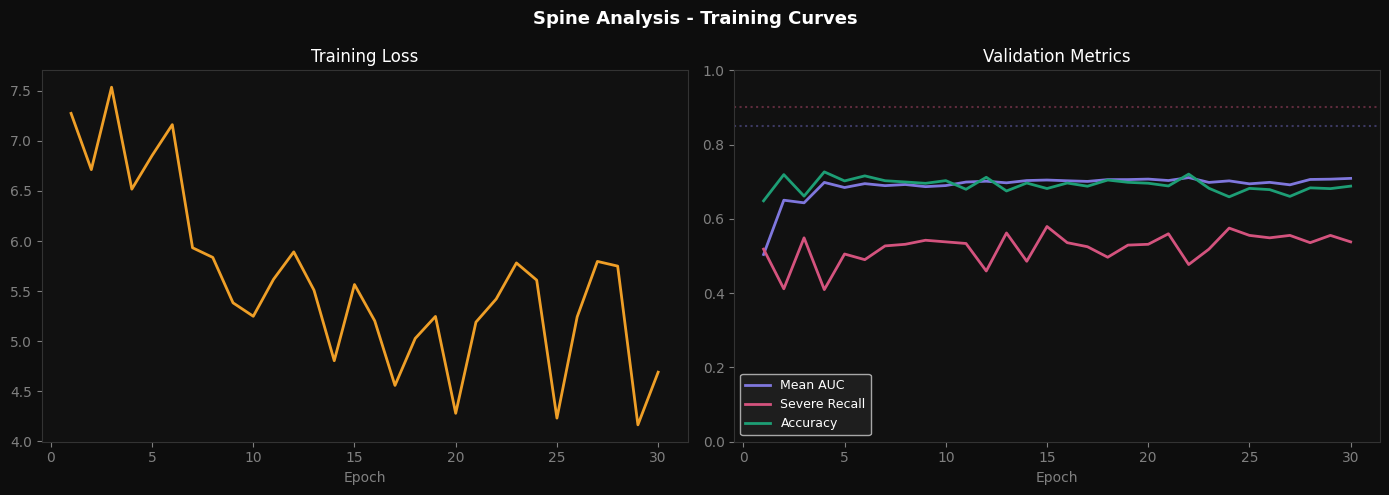

Best epoch      : 22
  Mean AUC      : 0.7112  (target >0.85)
  Severe Recall : 0.4771  (target >0.90)
  Accuracy      : 0.7205


In [11]:
import os, torch
import matplotlib.pyplot as plt

BASE   = r'C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI'
CKPT   = os.path.join(BASE, 'checkpoints', 'spine_cls')
OUT    = os.path.join(BASE, 'outputs', 'nb08b_spine')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

ckpt_path = os.path.join(CKPT, 'spine_last.pth')
if not os.path.exists(ckpt_path):
    print('No checkpoint - run training first')
else:
    history = torch.load(ckpt_path, map_location=DEVICE,
                         weights_only=False).get('history', [])

    epochs    = [h['epoch']      for h in history]
    losses    = [h['train_loss'] for h in history]
    aucs      = [h['mean_auc']   for h in history]
    sev_recs  = [h['severe_rec'] for h in history]
    accs      = [h['val_acc']    for h in history]

    plt.style.use('dark_background')
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor='#0d0d0d')
    fig.suptitle('Spine Analysis - Training Curves',
                 color='white', fontsize=13, fontweight='bold')

    axes[0].plot(epochs, losses, color='#EF9F27', linewidth=2)
    axes[0].set_title('Training Loss', color='white')
    axes[0].set_xlabel('Epoch', color='gray')
    axes[0].set_facecolor('#111')
    axes[0].spines[:].set_color('#333')
    axes[0].tick_params(colors='gray')

    axes[1].plot(epochs, aucs,     color='#7F77DD', linewidth=2, label='Mean AUC')
    axes[1].plot(epochs, sev_recs, color='#D4537E', linewidth=2, label='Severe Recall')
    axes[1].plot(epochs, accs,     color='#1D9E75', linewidth=2, label='Accuracy')
    axes[1].axhline(0.85, color='#7F77DD', linestyle=':', alpha=0.4)
    axes[1].axhline(0.90, color='#D4537E', linestyle=':', alpha=0.4)
    axes[1].set_title('Validation Metrics', color='white')
    axes[1].set_xlabel('Epoch', color='gray')
    axes[1].set_ylim(0, 1)
    axes[1].legend(fontsize=9, facecolor='#222', labelcolor='white')
    axes[1].set_facecolor('#111')
    axes[1].spines[:].set_color('#333')
    axes[1].tick_params(colors='gray')

    plt.tight_layout()
    plt.savefig(os.path.join(OUT, 'training_curves.png'), dpi=120,
                bbox_inches='tight', facecolor='#0d0d0d')
    plt.show()

    best = max(history, key=lambda h: h['mean_auc'])
    print(f'Best epoch      : {best["epoch"]}')
    print(f'  Mean AUC      : {best["mean_auc"]:.4f}  (target >0.85)')
    print(f'  Severe Recall : {best["severe_rec"]:.4f}  (target >0.90)')
    print(f'  Accuracy      : {best["val_acc"]:.4f}')

---
## Cell 11 - ONNX Export

In [12]:
import os, torch

BASE   = r'C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI'
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
OUT    = os.path.join(BASE, 'models', 'production', 'spine')
os.makedirs(OUT, exist_ok=True)

onnx_path = os.path.join(OUT, 'spine_hybridspinenet.onnx')

best_path = os.path.join(BASE, 'checkpoints', 'spine_cls', 'spine_best.pth')
if os.path.exists(best_path):
    ckpt = torch.load(best_path, map_location=DEVICE, weights_only=False)
    model.load_state_dict(ckpt['model_state_dict'])
    print(f'Loaded best model (epoch {ckpt["epoch"]})')

model.eval()
model.cpu()

# 3-input model requires custom export
d1 = torch.zeros(1, 3, 384, 384)

try:
    torch.onnx.export(
        model, (d1, d1, d1), onnx_path,
        export_params=True,
        opset_version=17,
        input_names=['sag_t1', 'sag_t2', 'ax_t2'],
        output_names=['logits', 'cauda_logit'],
        dynamic_axes={
            'sag_t1':      {0: 'batch_size'},
            'sag_t2':      {0: 'batch_size'},
            'ax_t2':       {0: 'batch_size'},
            'logits':      {0: 'batch_size'},
            'cauda_logit': {0: 'batch_size'},
        }
    )
    sz = os.path.getsize(onnx_path) / (1024**2)
    print(f'ONNX : {onnx_path}')
    print(f'Size : {sz:.1f} MB')

    import onnx, onnxruntime as ort
    onnx.checker.check_model(onnx.load(onnx_path))
    sess = ort.InferenceSession(onnx_path, providers=['CPUExecutionProvider'])
    outs = sess.run(None, {
        'sag_t1': d1.numpy(),
        'sag_t2': d1.numpy(),
        'ax_t2' : d1.numpy(),
    })
    print(f'Inference OK:')
    print(f'  logits      : {outs[0].shape}  (expected [1, 25, 3])')
    print(f'  cauda_logit : {outs[1].shape}  (expected [1, 1])')
    print('ONNX OK')
except Exception as e:
    print(f'ONNX failed: {e}')
finally:
    model.to(DEVICE)

Loaded best model (epoch 21)
ONNX : C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI\models\production\spine\spine_hybridspinenet.onnx
Size : 273.2 MB
Inference OK:
  logits      : (1, 25, 3)  (expected [1, 25, 3])
  cauda_logit : (1, 1)  (expected [1, 1])
ONNX OK


---
## Cell 12 - Summary

In [13]:
import os, torch

BASE   = r'C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI'
CKPT   = os.path.join(BASE, 'checkpoints', 'spine_cls')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print('=' * 65)
print('  NOTEBOOK 08B - LUMBAR SPINE ANALYSIS')
print('=' * 65)

for tag in ['best', 'last']:
    p = os.path.join(CKPT, f'spine_{tag}.pth')
    if os.path.exists(p):
        ckpt = torch.load(p, map_location=DEVICE, weights_only=False)
        m    = ckpt.get('metrics', {})
        print(f'  {tag:5} checkpoint: epoch {ckpt["epoch"]:3d}, '
              f'MeanAUC={m.get("mean_auc",0):.4f}, '
              f'SevRec={m.get("severe_rec",0):.4f}, '
              f'Acc={m.get("val_acc",0):.4f}')

onnx_p = os.path.join(BASE, 'models', 'production', 'spine',
                      'spine_hybridspinenet.onnx')
print(f'  ONNX : {"OK" if os.path.exists(onnx_p) else "not done yet"}')
print()
print('  Model       : HybridSpineNet (3 x EfficientNet-B4 + CrossViewAttention)')
print('  Targets     : 25 (5 conditions x 5 spinal levels)')
print('  Classes     : 3 (Normal/Mild, Moderate, Severe)')
print('  Dataset     : RSNA 2024 Lumbar Spine')
print('  Loss        : WeightedCE (1/3/10) + CaudaBCE (2x)')
print('  Cauda flag  : Severe bilateral spinal canal stenosis = Priority 1 alert')
print('  Targets     : MeanAUC >0.85, SevereRec >0.90, CaudaRec >0.95')
print()
print('  Next: 09_Ensemble_Consensus.ipynb')
print('    - Multi-model ensemble across all 6 pipelines')
print('    - Verification gate (97/99/95/93% thresholds)')
print('    - STAPLE for segmentation fusion')
print('=' * 65)

  NOTEBOOK 08B - LUMBAR SPINE ANALYSIS
  best  checkpoint: epoch  21, MeanAUC=0.7112, SevRec=0.4771, Acc=0.7205
  last  checkpoint: epoch  29, MeanAUC=0.7091, SevRec=0.5381, Acc=0.6882
  ONNX : OK

  Model       : HybridSpineNet (3 x EfficientNet-B4 + CrossViewAttention)
  Targets     : 25 (5 conditions x 5 spinal levels)
  Classes     : 3 (Normal/Mild, Moderate, Severe)
  Dataset     : RSNA 2024 Lumbar Spine
  Loss        : WeightedCE (1/3/10) + CaudaBCE (2x)
  Cauda flag  : Severe bilateral spinal canal stenosis = Priority 1 alert
  Targets     : MeanAUC >0.85, SevereRec >0.90, CaudaRec >0.95

  Next: 09_Ensemble_Consensus.ipynb
    - Multi-model ensemble across all 6 pipelines
    - Verification gate (97/99/95/93% thresholds)
    - STAPLE for segmentation fusion
